In [1]:
# ── CELL 1 ── Imports, seed, device ─────────────────────────────────────────────────────────
import os, sys, json, time, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime
from collections import defaultdict
from pathlib import Path

import cv2
import torch
import torchvision.transforms as T
from PIL import Image as PILImage
from ultralytics import YOLO as UltralyticsYOLO
import timm

from skimage.feature import local_binary_pattern, graycomatrix, graycoprops, hog
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score
import joblib

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE      = torch.device("mps")
    YOLO_DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE      = torch.device("cuda")
    YOLO_DEVICE = "0"
else:
    DEVICE      = torch.device("cpu")
    YOLO_DEVICE = "cpu"

CLASS_NAMES = ["BIODEGRADABLE", "CARDBOARD", "GLASS", "METAL", "PAPER", "PLASTIC"]
N_CLASSES   = 6

print(f"PyTorch device    : {DEVICE}")
print(f"Ultralytics device: {YOLO_DEVICE}")
print("Imports OK — E13 Three-Way DA + Late Fusion")


/Users/nadaashraf/Desktop/CV-Project/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch device    : mps
Ultralytics device: mps
Imports OK — E13 Three-Way DA + Late Fusion


In [2]:
# ── CELL 2 ── Paths ──────────────────────────────────────────────────────────────────────────
_local = os.path.expanduser("~/Desktop/CV-Project")
_colab = "/content/drive/MyDrive/CV/repo"
REPO_ROOT = _colab if os.path.isdir(_colab) else (_local if os.path.isdir(_local) else os.getcwd())

FEAT_DIR    = os.path.join(REPO_ROOT, "data", "processed", "features")
TRAIN_IMG   = os.path.join(FEAT_DIR, "train", "images")
TRAIN_LBL   = os.path.join(FEAT_DIR, "train", "labels")
VAL_IMG     = os.path.join(FEAT_DIR, "val",   "images")
VAL_LBL     = os.path.join(FEAT_DIR, "val",   "labels")
TEST_IMG    = os.path.join(FEAT_DIR, "test",  "images")
TEST_LBL    = os.path.join(FEAT_DIR, "test",  "labels")
MODELS_DIR  = os.path.join(REPO_ROOT, "models")
RESULTS_DIR = os.path.join(REPO_ROOT, "results", "metrics")
FIGS_DIR    = os.path.join(REPO_ROOT, "figures", "detection")
CKPT_DIR    = os.path.join(REPO_ROOT, "data", "processed", "da_checkpoints")

YOLO_WEIGHTS = os.path.join(FEAT_DIR, "yolov8n_E1_best.pt")

# ── E11-DA checkpoints (reused as-is, never regenerated) ──
DA_YOLO_FEAT  = os.path.join(CKPT_DIR, "da_yolo_train_X.npy")
DA_CLAS_FEAT  = os.path.join(CKPT_DIR, "da_classical_train_X.npy")
DA_LABELS     = os.path.join(CKPT_DIR, "da_train_y.npy")
MERGED_JSON   = os.path.join(CKPT_DIR, "da_matched_merged.json")

# ── E13 new checkpoints ──
DA_EFFNET_FEAT = os.path.join(CKPT_DIR, "da_efficientnet_train_X.npy")
VAL_PREDS_NPZ  = os.path.join(CKPT_DIR, "e13_val_preds.npz")
TEST_PREDS_NPZ = os.path.join(CKPT_DIR, "e13_test_preds.npz")

E13_SCALERS = os.path.join(MODELS_DIR, "e13_scalers.pkl")
E13_PCA     = os.path.join(MODELS_DIR, "e13_pca.pkl")
E13_SVM     = os.path.join(MODELS_DIR, "e13_svm.pkl")

for d in [MODELS_DIR, RESULTS_DIR, FIGS_DIR, CKPT_DIR]:
    os.makedirs(d, exist_ok=True)

required = [
    (TRAIN_IMG, "Train images"),  (TRAIN_LBL, "Train labels"),
    (VAL_IMG,   "Val images"),    (VAL_LBL,   "Val labels"),
    (TEST_IMG,  "Test images"),   (TEST_LBL,  "Test labels"),
    (YOLO_WEIGHTS, "YOLO weights"),
    (DA_YOLO_FEAT, "DA SPPF train feats (E11-DA)"),
    (DA_CLAS_FEAT, "DA Classical train feats (E11-DA)"),
    (DA_LABELS,    "DA train labels (E11-DA)"),
    (MERGED_JSON,  "DA merged crop manifest (E11-DA)"),
]
for path, label in required:
    mark = "✓" if os.path.exists(path) else "✗ MISSING"
    print(f"  {mark}  {label}")

print(f"\nREPO_ROOT = {REPO_ROOT}")



  ✓  Train images
  ✓  Train labels
  ✓  Val images
  ✓  Val labels
  ✓  Test images
  ✓  Test labels
  ✓  YOLO weights
  ✓  DA SPPF train feats (E11-DA)
  ✓  DA Classical train feats (E11-DA)
  ✓  DA train labels (E11-DA)
  ✓  DA merged crop manifest (E11-DA)

REPO_ROOT = /Users/nadaashraf/Desktop/CV-Project


In [3]:
# ── CELL 3 ── Baseline constants ─────────────────────────────────────────────────────────────
E1_MAP50    = 0.4559
E11_MAP50   = 0.3840
E11DA_MAP50 = 0.3897

E1_PER_CLASS = {
    "BIODEGRADABLE": 0.4663, "CARDBOARD": 0.4445, "GLASS": 0.4575,
    "METAL": 0.5161,         "PAPER":     0.3939, "PLASTIC": 0.4572,
}
E11_PER_CLASS = {
    "BIODEGRADABLE": 0.4441, "CARDBOARD": 0.3915, "GLASS": 0.3826,
    "METAL": 0.4065,         "PAPER":     0.3256, "PLASTIC": 0.3537,
}
E11DA_PER_CLASS = {
    "BIODEGRADABLE": 0.4426, "CARDBOARD": 0.3956, "GLASS": 0.3837,
    "METAL": 0.4175,         "PAPER":     0.3414, "PLASTIC": 0.3577,
}

YOLO_CONF_THRESH = 0.25
YOLO_IOU_THRESH  = 0.45
GT_MATCH_IOU     = 0.50

print(f"E1 baseline mAP@0.5   : {E1_MAP50}")
print(f"E11 domain-naive      : {E11_MAP50}")
print(f"E11-DA domain-adapted : {E11DA_MAP50}  ← E13 must beat this")


E1 baseline mAP@0.5   : 0.4559
E11 domain-naive      : 0.384
E11-DA domain-adapted : 0.3897  ← E13 must beat this


In [4]:
# ── CELL 4 ── Load YOLO + SPPF hook ──────────────────────────────────────────────────────────
# Identical to E11-DA Cell 4 — hook fires on YOLO backbone layer 9 (SPPF)

yolo_detector = UltralyticsYOLO(YOLO_WEIGHTS)
yolo_detector.model.eval()
yolo_detector.model.to(DEVICE)
nn_backbone = yolo_detector.model

_sppf_buf    = {}
_sppf_handle = nn_backbone.model[9].register_forward_hook(
    lambda m, inp, out: _sppf_buf.update({"feat": out.detach()})
)

_yolo_transform = T.Compose([T.ToTensor()])  # /255 only — no ImageNet normalisation

def extract_sppf(crop_rgb_224: np.ndarray) -> np.ndarray:
    """YOLOv8n backbone → GAP on SPPF output → (256,)."""
    dev = next(nn_backbone.parameters()).device
    t   = _yolo_transform(PILImage.fromarray(crop_rgb_224)).unsqueeze(0).to(dev)
    with torch.no_grad():
        nn_backbone(t)
    return _sppf_buf["feat"].mean(dim=[2, 3]).cpu().numpy().flatten()

_dummy = np.zeros((224, 224, 3), dtype=np.uint8)
assert extract_sppf(_dummy).shape == (256,), "SPPF shape mismatch"
print("YOLO loaded — SPPF hook on model[9] — output (256,) ✓")


YOLO loaded — SPPF hook on model[9] — output (256,) ✓


In [5]:
# ── CELL 5 ── Classical feature extractor (252-dim) ──────────────────────────────────────────
# Verbatim copy of src/features/classical_features.py
# Color(96) + LBP(26) + Gabor(48) + HOG(36) + Shape(10) + GLCM(36) = 252

def _color_histogram(img_rgb, bins=32):
    img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    return np.concatenate([
        np.histogram(img_hsv[:, :, ch], bins=bins, range=(0, 256), density=True)[0]
        for ch in range(3)
    ])  # 96

def _lbp(gray, n_points=24, radius=3):
    lbp = local_binary_pattern(gray, n_points, radius, method="uniform")
    hist, _ = np.histogram(lbp.ravel(), bins=n_points+2, range=(0, n_points+2), density=True)
    return hist  # 26

def _gabor(gray):
    feats = []
    for freq in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]:
        for theta in [0, np.pi/4, np.pi/2, 3*np.pi/4]:
            k = cv2.getGaborKernel((21, 21), 5, theta, 1/freq, 0.5, 0, ktype=cv2.CV_32F)
            f = cv2.filter2D(gray.astype(np.float32), cv2.CV_32F, k)
            feats.extend([f.mean(), f.std()])
    return np.array(feats)  # 48

def _hog_feats(gray):
    feats = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                cells_per_block=(2, 2), feature_vector=True)
    return feats[:36] if len(feats) >= 36 else np.pad(feats, (0, 36 - len(feats)))  # 36

def _shape(gray):
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return np.zeros(10)
    cnt  = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(cnt)
    peri = cv2.arcLength(cnt, True)
    x, y, w, h = cv2.boundingRect(cnt)
    return np.array([
        w / (h + 1e-6),
        4 * np.pi * area / (peri**2 + 1e-6),
        area / (w * h + 1e-6),
        *cv2.HuMoments(cv2.moments(cnt)).flatten()[:7],
    ])  # 10

def _glcm(gray):
    glcm = graycomatrix(gray, distances=[1, 3],
                        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=256, symmetric=True, normed=True)
    raw = np.concatenate([graycoprops(glcm, p).ravel()
                          for p in ["contrast","dissimilarity","homogeneity","energy","correlation"]])
    return raw[:36]  # 36

def extract_classical(img_rgb_224: np.ndarray) -> np.ndarray:
    gray  = cv2.cvtColor(img_rgb_224, cv2.COLOR_RGB2GRAY)
    feats = np.concatenate([
        _color_histogram(img_rgb_224),
        _lbp(gray), _gabor(gray), _hog_feats(gray), _shape(gray), _glcm(gray),
    ])
    assert len(feats) == 252, f"Classical dim: {len(feats)}"
    return feats

assert extract_classical(_dummy).shape == (252,), "Classical shape mismatch"
print("Classical extractor OK — (252,) ✓")


Classical extractor OK — (252,) ✓


In [6]:
# ── CELL 6 ── EfficientNetB0 extractor (1280-dim) — NEW vs E11-DA ────────────────────────────
# Uses ImageNet normalisation (different from SPPF which uses /255 only).
# Both backbones receive a separate copy of the same 224×224 RGB crop.

_effnet_model = timm.create_model("efficientnet_b0", pretrained=True, num_classes=0)
_effnet_model.eval()
_effnet_model.to(DEVICE)

_effnet_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def extract_efficientnet(crop_rgb_224: np.ndarray) -> np.ndarray:
    """EfficientNetB0 global-pooled output → (1280,)."""
    t = _effnet_transform(PILImage.fromarray(crop_rgb_224)).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        feat = _effnet_model(t)
    return feat.cpu().numpy().flatten()

assert extract_efficientnet(_dummy).shape == (1280,), "EfficientNet shape mismatch"
print("EfficientNetB0 loaded — (1280,) ✓")

EfficientNetB0 loaded — (1280,) ✓


In [7]:
# ── CELL 7 ── Utility functions ───────────────────────────────────────────────────────────────

def box_iou(a, b):
    """IoU between two [x1,y1,x2,y2] boxes."""
    xi1, yi1 = max(a[0], b[0]), max(a[1], b[1])
    xi2, yi2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0.0, xi2 - xi1) * max(0.0, yi2 - yi1)
    if inter == 0.0:
        return 0.0
    return inter / ((a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter + 1e-6)

def parse_gt(label_path, img_w, img_h):
    """Parse YOLO-format .txt → list of (cls, x1, y1, x2, y2) in pixels."""
    boxes = []
    if not os.path.isfile(label_path):
        return boxes
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls = int(parts[0])
            xc, yc, w, h = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
            boxes.append((cls,
                          (xc - w/2) * img_w, (yc - h/2) * img_h,
                          (xc + w/2) * img_w, (yc + h/2) * img_h))
    return boxes

def safe_crop_resize(img_rgb, x1, y1, x2, y2, size=224):
    """Crop bbox from image, clamp to bounds, resize to size×size. Returns None if too small."""
    H, W = img_rgb.shape[:2]
    x1c, y1c = max(0, int(x1)), max(0, int(y1))
    x2c, y2c = min(W, int(x2)), min(H, int(y2))
    if x2c <= x1c or y2c <= y1c or min(x2c-x1c, y2c-y1c) < 8:
        return None
    crop = img_rgb[y1c:y2c, x1c:x2c]
    return cv2.resize(crop, (size, size), interpolation=cv2.INTER_LINEAR) if crop.size else None

def _voc_ap(rec, prec):
    """PASCAL VOC 2010 AP — area under interpolated PR curve."""
    mrec = np.concatenate(([0.0], rec, [1.0]))
    mpre = np.concatenate(([0.0], prec, [0.0]))
    for k in range(mpre.size - 1, 0, -1):
        mpre[k-1] = max(mpre[k-1], mpre[k])
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    return float(np.sum((mrec[idx+1] - mrec[idx]) * mpre[idx+1]))

def compute_map50(preds_by_cls, gt_by_cls, iou_thresh=0.5):
    """
    preds_by_cls : {cls: [(img_id, [x1,y1,x2,y2], confidence)]}
    gt_by_cls    : {cls: [(img_id, [x1,y1,x2,y2])]}
    Returns (map50, {cls: ap})
    """
    per_cls = {}
    for cls in range(N_CLASSES):
        preds = sorted(preds_by_cls.get(cls, []), key=lambda x: -x[2])
        gts   = gt_by_cls.get(cls, [])
        n_gt  = len(gts)
        if n_gt == 0 or not preds:
            per_cls[cls] = 0.0
            continue
        gt_img = defaultdict(list)
        for img_id, box in gts:
            gt_img[img_id].append({"box": box, "matched": False})
        tp = np.zeros(len(preds))
        fp = np.zeros(len(preds))
        for j, (img_id, pred_box, _) in enumerate(preds):
            candidates = gt_img.get(img_id, [])
            best_iou, best_k = 0.0, -1
            for k, gt in enumerate(candidates):
                iou_val = box_iou(pred_box, gt["box"])
                if iou_val > best_iou:
                    best_iou, best_k = iou_val, k
            if best_iou >= iou_thresh and best_k >= 0 and not candidates[best_k]["matched"]:
                tp[j] = 1
                candidates[best_k]["matched"] = True
            else:
                fp[j] = 1
        cum_tp = np.cumsum(tp)
        cum_fp = np.cumsum(fp)
        rec    = cum_tp / n_gt
        prec   = cum_tp / (cum_tp + cum_fp + 1e-6)
        per_cls[cls] = _voc_ap(rec, prec)
    return float(np.mean(list(per_cls.values()))), per_cls

print("Utilities ready: box_iou, parse_gt, safe_crop_resize, compute_map50")



Utilities ready: box_iou, parse_gt, safe_crop_resize, compute_map50


In [8]:

# ── CELL 8 ── Extract EfficientNetB0 features on DA training crops ────────────────────────────
#
# E11-DA already computed da_yolo_train_X.npy and da_classical_train_X.npy.
# This cell adds the missing EfficientNetB0 branch on the SAME crops in the same order.
# Checkpoint: if da_efficientnet_train_X.npy exists, load it and skip extraction.

if os.path.isfile(DA_EFFNET_FEAT):
    print(f"EfficientNet DA checkpoint found — loading…")
    X_effnet_da = np.load(DA_EFFNET_FEAT)
    X_yolo_da   = np.load(DA_YOLO_FEAT)
    X_clas_da   = np.load(DA_CLAS_FEAT)
    y_da        = np.load(DA_LABELS)
    print(f"  EfficientNet : {X_effnet_da.shape}")
    print(f"  SPPF         : {X_yolo_da.shape}")
    print(f"  Classical    : {X_clas_da.shape}")
    print(f"  Labels       : {y_da.shape}")
    assert X_effnet_da.shape[0] == X_yolo_da.shape[0] == X_clas_da.shape[0], \
        "Row count mismatch — delete DA_EFFNET_FEAT and re-run"

else:
    print("Loading E11-DA feature arrays and crop manifest…")
    X_yolo_da = np.load(DA_YOLO_FEAT)
    X_clas_da = np.load(DA_CLAS_FEAT)
    y_da      = np.load(DA_LABELS)
    with open(MERGED_JSON) as f:
        matched_samples = json.load(f)

    n_da = X_yolo_da.shape[0]
    print(f"Manifest has {len(matched_samples):,} entries; feature arrays have {n_da:,} rows.")
    print("Extracting EfficientNetB0 features on DA training crops…")
    print("Estimated: 8–15 min (Colab T4), 20–40 min (CPU).\n")

    effnet_list  = []
    valid_mask   = []
    skipped      = 0
    t0           = time.time()

    # We only iterate over the first n_da manifest entries (some were skipped in E11-DA
    # due to bad crops/missing images — we must mirror the same skip pattern).
    # Strategy: rebuild the index by iterating manifest and replicating E11-DA's skip logic,
    # but we already have y_da which is the ground-truth label sequence for the n_da rows.
    # The safest approach: re-iterate manifest in order, skip on the same conditions, and
    # collect EfficientNet features. The resulting array must have exactly n_da rows.

    feat_idx = 0
    for i, sample in enumerate(matched_samples):
        if feat_idx >= n_da:
            break  # collected enough

        img_bgr = cv2.imread(sample["image"])
        if img_bgr is None:
            skipped += 1
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        crop = safe_crop_resize(img_rgb, *sample["bbox"])
        if crop is None:
            skipped += 1
            continue
        try:
            feat = extract_efficientnet(crop)
        except Exception:
            skipped += 1
            continue

        effnet_list.append(feat)
        feat_idx += 1

        if feat_idx % 1000 == 0:
            elapsed = time.time() - t0
            eta     = (n_da - feat_idx) / max(feat_idx / elapsed, 1e-6)
            print(f"  [{feat_idx}/{n_da}]  skip={skipped}  "
                  f"rate={feat_idx/elapsed:.1f}/s  ETA={eta:.0f}s ({eta/60:.1f} min)")

    if len(effnet_list) != n_da:
        raise RuntimeError(
            f"EfficientNet extraction yielded {len(effnet_list)} rows "
            f"but expected {n_da} (same as SPPF/Classical arrays). "
            f"This means the manifest has fewer valid crops than the E11-DA arrays assumed. "
            f"Delete da_yolo_train_X.npy and re-run E11-DA Cell 8 + this cell together."
        )

    X_effnet_da = np.array(effnet_list, dtype=np.float32)

    # Sanity: drop NaN/Inf
    finite = np.isfinite(X_effnet_da).all(axis=1)
    if (~finite).sum() > 0:
        bad = (~finite).sum()
        print(f"Dropping {bad} samples with NaN/Inf in EfficientNet features")
        X_effnet_da = X_effnet_da[finite]
        X_yolo_da   = X_yolo_da[finite]
        X_clas_da   = X_clas_da[finite]
        y_da        = y_da[finite]

    np.save(DA_EFFNET_FEAT, X_effnet_da)
    elapsed = time.time() - t0
    print(f"\nExtraction complete in {elapsed:.0f}s ({elapsed/60:.1f} min)")
    print(f"Saved → {DA_EFFNET_FEAT}")

print(f"\nDA training set ready: {len(y_da):,} samples")
for cls_id, name in enumerate(CLASS_NAMES):
    cnt = (y_da == cls_id).sum()
    print(f"  {name:<18}: {cnt:>6,}  ({cnt/len(y_da)*100:.1f}%)")



Loading E11-DA feature arrays and crop manifest…
Manifest has 51,632 entries; feature arrays have 51,624 rows.
Extracting EfficientNetB0 features on DA training crops…
Estimated: 8–15 min (Colab T4), 20–40 min (CPU).

  [1000/51624]  skip=0  rate=136.3/s  ETA=371s (6.2 min)
  [2000/51624]  skip=0  rate=139.6/s  ETA=355s (5.9 min)
  [3000/51624]  skip=0  rate=140.9/s  ETA=345s (5.8 min)
  [4000/51624]  skip=1  rate=140.8/s  ETA=338s (5.6 min)
  [5000/51624]  skip=1  rate=139.9/s  ETA=333s (5.6 min)
  [6000/51624]  skip=1  rate=140.8/s  ETA=324s (5.4 min)
  [7000/51624]  skip=2  rate=140.8/s  ETA=317s (5.3 min)
  [8000/51624]  skip=2  rate=141.2/s  ETA=309s (5.2 min)
  [9000/51624]  skip=2  rate=140.8/s  ETA=303s (5.0 min)
  [10000/51624]  skip=2  rate=141.0/s  ETA=295s (4.9 min)
  [11000/51624]  skip=3  rate=140.9/s  ETA=288s (4.8 min)
  [12000/51624]  skip=3  rate=140.9/s  ETA=281s (4.7 min)
  [13000/51624]  skip=4  rate=141.1/s  ETA=274s (4.6 min)
  [14000/51624]  skip=6  rate=141.1/s

In [9]:

# ── CELL 9 ── Fit DA scalers + PCA + train E13 SVM ───────────────────────────────────────────
#
# All three scalers and the PCA are fit on the DA-distribution (predicted+jitter crops),
# NOT on the GT-crop distribution used by E12. This is the key difference that ensures
# the entire feature pipeline is calibrated to the inference distribution.

if all(os.path.isfile(p) for p in [E13_SCALERS, E13_PCA, E13_SVM]):
    print("E13 models already saved — loading…")
    saved = joblib.load(E13_SCALERS)
    sc_yolo, sc_deep, sc_clas = saved["sc_yolo"], saved["sc_deep"], saved["sc_clas"]
    pca_e13 = joblib.load(E13_PCA)
    svm_e13 = joblib.load(E13_SVM)
    print(f"  PCA components : {pca_e13.n_components_}")
    print(f"  SVM n_support  : {sum(svm_e13.n_support_)}")

else:
    # Step 1: per-modality scaling on DA distribution
    print("Fitting per-modality StandardScalers on DA distribution…")
    sc_yolo = StandardScaler()
    sc_deep = StandardScaler()
    sc_clas = StandardScaler()

    X_yolo_s = sc_yolo.fit_transform(X_yolo_da)
    X_deep_s = sc_deep.fit_transform(X_effnet_da)
    X_clas_s = sc_clas.fit_transform(X_clas_da)

    X_fused  = np.hstack([X_yolo_s, X_deep_s, X_clas_s])  # (N, 1788)
    print(f"Fused dim : {X_fused.shape[1]}  (SPPF 256 + EfficientNet 1280 + Classical 252)")

    # Step 2: PCA(95%) on DA-distribution fused features
    print("Fitting PCA(95% variance)…")
    t0      = time.time()
    pca_e13 = PCA(n_components=0.95, svd_solver="full", random_state=SEED)
    X_pca   = pca_e13.fit_transform(X_fused)
    n_comp  = pca_e13.n_components_
    var_ret = float(pca_e13.explained_variance_ratio_.sum())
    print(f"  PCA done in {time.time()-t0:.1f}s")
    print(f"  Retained {n_comp} components from 1788  ({var_ret*100:.2f}% variance)")
    print(f"  Train PCA shape: {X_pca.shape}")

    # Step 3: val sanity check on GT crops (same protocol as E11-DA)
    print("\nVal sanity check (GT crops, rough signal only)…")
    X_yolo_gt_val = np.load(os.path.join(FEAT_DIR, "yolo_val_X.npy"))
    X_deep_gt_val = np.load(os.path.join(FEAT_DIR, "deep_val_X.npy"))
    X_clas_gt_val = np.load(os.path.join(FEAT_DIR, "classical_val_X.npy"))
    y_val_gt      = np.load(os.path.join(FEAT_DIR, "classical_val_y.npy"))

    X_val_fused = np.hstack([
        sc_yolo.transform(X_yolo_gt_val),
        sc_deep.transform(X_deep_gt_val),
        sc_clas.transform(X_clas_gt_val),
    ])
    X_val_pca = pca_e13.transform(X_val_fused)

    # Step 4: train SVM
    print(f"\nTraining SVM(RBF, C=10, balanced)…  [{len(y_da):,} samples × {n_comp} dims]")
    t0 = time.time()
    svm_e13 = SVC(
        kernel="rbf", C=10, gamma="scale",
        probability=True, class_weight="balanced",
        random_state=SEED, max_iter=5000,
    )
    svm_e13.fit(X_pca, y_da)
    fit_time = time.time() - t0
    print(f"SVM training done in {fit_time:.0f}s ({fit_time/60:.1f} min)")

    val_pred     = svm_e13.predict(X_val_pca)
    val_macro_f1 = f1_score(y_val_gt, val_pred, average="macro")
    val_acc      = accuracy_score(y_val_gt, val_pred)
    print(f"Val (GT crops) accuracy : {val_acc:.4f}")
    print(f"Val (GT crops) macro-F1 : {val_macro_f1:.4f}")
    print("(Cross-distribution gap vs E12 GT-trained SVM is expected — see methodology §3.3)")

    # Save all three artifacts
    joblib.dump({"sc_yolo": sc_yolo, "sc_deep": sc_deep, "sc_clas": sc_clas}, E13_SCALERS)
    joblib.dump(pca_e13, E13_PCA)
    joblib.dump(svm_e13, E13_SVM)
    print(f"\nSaved scalers → {E13_SCALERS}")
    print(f"Saved PCA     → {E13_PCA}")
    print(f"Saved SVM     → {E13_SVM}  ({os.path.getsize(E13_SVM)/1e6:.1f} MB)")



Fitting per-modality StandardScalers on DA distribution…
Fused dim : 1788  (SPPF 256 + EfficientNet 1280 + Classical 252)
Fitting PCA(95% variance)…
  PCA done in 3.0s
  Retained 1098 components from 1788  (95.01% variance)
  Train PCA shape: (51624, 1098)

Val sanity check (GT crops, rough signal only)…

Training SVM(RBF, C=10, balanced)…  [51,624 samples × 1098 dims]
SVM training done in 1345s (22.4 min)
Val (GT crops) accuracy : 0.8845
Val (GT crops) macro-F1 : 0.8068
(Cross-distribution gap vs E12 GT-trained SVM is expected — see methodology §3.3)

Saved scalers → /Users/nadaashraf/Desktop/CV-Project/models/e13_scalers.pkl
Saved PCA     → /Users/nadaashraf/Desktop/CV-Project/models/e13_pca.pkl
Saved SVM     → /Users/nadaashraf/Desktop/CV-Project/models/e13_svm.pkl  (163.3 MB)


In [10]:

# ── CELL 10 ── Inference helper (shared by val and test) ─────────────────────────────────────
#
# run_inference(img_dir, lbl_dir) →
#   detections : list of dicts {img_id, bbox, yolo_conf, p_yolo[6], p_svm[6]}
#   gt_by_cls  : {cls: [(img_id, [x1,y1,x2,y2])]}
#
# YOLO class probability vector p_yolo is constructed from detection output:
#   p_yolo[yolo_cls] = yolo_conf  (max-class detection confidence)
#   p_yolo[others]   = (1 - yolo_conf) / 5  (uniform residual)
# This approximation is consistent with YOLO's internal sigmoid/softmax class head
# and is standard practice when the full per-box class distribution is unavailable
# from the ultralytics predict() API.

def run_inference(img_dir, lbl_dir, desc=""):
    """
    Run YOLO localisation + E13 SVM classification on all images in img_dir.
    Returns (detections, gt_by_cls).
      detections : list of {img_id, bbox, yolo_conf, p_yolo, p_svm}
      gt_by_cls  : {cls_id: [(img_id, [x1,y1,x2,y2])]}
    """
    img_paths   = sorted(list(Path(img_dir).glob("*.jpg")) + list(Path(img_dir).glob("*.png")))
    detections  = []
    gt_by_cls   = defaultdict(list)
    skipped_det = 0
    t0          = time.time()

    print(f"Running E13 inference on {len(img_paths)} {desc} images…")

    for i, img_path in enumerate(img_paths):
        img_id = img_path.stem

        results = yolo_detector.predict(
            str(img_path), conf=YOLO_CONF_THRESH, iou=YOLO_IOU_THRESH,
            device=YOLO_DEVICE, verbose=False, save=False,
        )
        result      = results[0]
        img_h, img_w = result.orig_shape

        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # Collect GT for mAP evaluation
        lbl_path = os.path.join(lbl_dir, img_path.stem + ".txt")
        for (gt_cls, gx1, gy1, gx2, gy2) in parse_gt(lbl_path, img_w, img_h):
            gt_by_cls[gt_cls].append((img_id, [gx1, gy1, gx2, gy2]))

        if result.boxes is None or len(result.boxes) == 0:
            continue

        for det in result.boxes:
            x1, y1, x2, y2 = det.xyxy[0].cpu().numpy().tolist()
            yolo_conf  = float(det.conf[0].cpu().numpy())
            yolo_cls   = int(det.cls[0].cpu().numpy())

            crop = safe_crop_resize(img_rgb, x1, y1, x2, y2)
            if crop is None:
                skipped_det += 1
                continue

            try:
                sppf_feat   = extract_sppf(crop)        # (256,)
                effnet_feat = extract_efficientnet(crop) # (1280,)
                clas_feat   = extract_classical(crop)    # (252,)
            except Exception:
                skipped_det += 1
                continue

            # Scale → fuse → PCA → SVM
            fused = np.hstack([
                sc_yolo.transform(sppf_feat.reshape(1, -1)),
                sc_deep.transform(effnet_feat.reshape(1, -1)),
                sc_clas.transform(clas_feat.reshape(1, -1)),
            ])
            pca_vec = pca_e13.transform(fused)
            p_svm   = svm_e13.predict_proba(pca_vec)[0]  # (6,)

            # Construct soft YOLO probability vector from detection confidence
            p_yolo = np.full(N_CLASSES, (1.0 - yolo_conf) / (N_CLASSES - 1), dtype=np.float32)
            p_yolo[yolo_cls] = yolo_conf

            detections.append({
                "img_id":    img_id,
                "bbox":      [x1, y1, x2, y2],
                "yolo_conf": yolo_conf,
                "p_yolo":    p_yolo.tolist(),
                "p_svm":     p_svm.tolist(),
            })

        if (i + 1) % 200 == 0:
            print(f"  [{i+1}/{len(img_paths)}]  dets={len(detections):,}  "
                  f"skip={skipped_det}  elapsed={time.time()-t0:.0f}s")

    elapsed = time.time() - t0
    print(f"Done in {elapsed:.0f}s — {len(detections):,} detections, {skipped_det} skipped")
    return detections, gt_by_cls

print("run_inference() defined — ready for Cell 11")

run_inference() defined — ready for Cell 11


In [11]:

# ── CELL 11 ── Val inference (for alpha sweep) ───────────────────────────────────────────────

if os.path.isfile(VAL_PREDS_NPZ):
    print(f"Val inference checkpoint found — loading…")
    saved_val = np.load(VAL_PREDS_NPZ, allow_pickle=True)
    val_dets     = saved_val["detections"].tolist()
    val_gt_arr   = saved_val["gt_by_cls"].tolist()
    val_gt_by_cls = defaultdict(list, {int(k): v for k, v in val_gt_arr.items()})
    print(f"  Val detections: {len(val_dets):,}")

else:
    val_dets, val_gt_by_cls = run_inference(VAL_IMG, VAL_LBL, desc="val")
    np.savez(VAL_PREDS_NPZ,
             detections=np.array(val_dets, dtype=object),
             gt_by_cls=np.array(dict(val_gt_by_cls), dtype=object))
    print(f"Checkpoint saved → {VAL_PREDS_NPZ}")


Running E13 inference on 1570 val images…
  [200/1570]  dets=2,898  skip=0  elapsed=229s
  [400/1570]  dets=4,841  skip=0  elapsed=380s
  [600/1570]  dets=5,328  skip=0  elapsed=420s
  [800/1570]  dets=5,916  skip=1  elapsed=468s
  [1000/1570]  dets=6,731  skip=4  elapsed=533s
  [1200/1570]  dets=7,343  skip=4  elapsed=582s
  [1400/1570]  dets=7,794  skip=4  elapsed=620s
Done in 666s — 8,377 detections, 4 skipped
Checkpoint saved → /Users/nadaashraf/Desktop/CV-Project/data/processed/da_checkpoints/e13_val_preds.npz


In [12]:

# ── CELL 12 ── Test inference ────────────────────────────────────────────────────────────────

if os.path.isfile(TEST_PREDS_NPZ):
    print(f"Test inference checkpoint found — loading…")
    saved_test = np.load(TEST_PREDS_NPZ, allow_pickle=True)
    test_dets    = saved_test["detections"].tolist()
    test_gt_arr  = saved_test["gt_by_cls"].tolist()
    test_gt_by_cls = defaultdict(list, {int(k): v for k, v in test_gt_arr.items()})
    print(f"  Test detections: {len(test_dets):,}")

else:
    test_dets, test_gt_by_cls = run_inference(TEST_IMG, TEST_LBL, desc="test")
    np.savez(TEST_PREDS_NPZ,
             detections=np.array(test_dets, dtype=object),
             gt_by_cls=np.array(dict(test_gt_by_cls), dtype=object))
    print(f"Checkpoint saved → {TEST_PREDS_NPZ}")


Running E13 inference on 1570 test images…
  [200/1570]  dets=2,485  skip=0  elapsed=199s
  [400/1570]  dets=4,685  skip=1  elapsed=376s
  [600/1570]  dets=5,248  skip=1  elapsed=422s
  [800/1570]  dets=5,837  skip=1  elapsed=471s
  [1000/1570]  dets=6,545  skip=1  elapsed=529s
  [1200/1570]  dets=7,394  skip=1  elapsed=599s
  [1400/1570]  dets=7,747  skip=1  elapsed=630s
Done in 679s — 8,340 detections, 1 skipped
Checkpoint saved → /Users/nadaashraf/Desktop/CV-Project/data/processed/da_checkpoints/e13_test_preds.npz


In [13]:

# ── CELL 13 ── Alpha grid sweep on validation ────────────────────────────────────────────────
#
# p_fused = α · p_YOLO + (1−α) · p_SVM
# final_class = argmax(p_fused)
# detection confidence for mAP ranking stays YOLO's objectness score (unchanged)
#
# Boundary cases recover prior experiments:
#   α = 1.0 → pure YOLO classification (≈ E1, modulo exact NMS ordering)
#   α = 0.0 → pure E13 SVM override (analogous to E11-DA with stronger features)

alpha_grid = np.round(np.arange(0.0, 1.05, 0.05), 2)
val_map_by_alpha = {}

print(f"Alpha sweep over {len(alpha_grid)} values on validation set…")

for alpha in alpha_grid:
    preds_by_cls = defaultdict(list)
    for det in val_dets:
        p_yolo = np.array(det["p_yolo"])
        p_svm  = np.array(det["p_svm"])
        p_fused = alpha * p_yolo + (1.0 - alpha) * p_svm
        final_cls = int(np.argmax(p_fused))
        preds_by_cls[final_cls].append(
            (det["img_id"], det["bbox"], det["yolo_conf"])
        )
    map50, _ = compute_map50(preds_by_cls, val_gt_by_cls)
    val_map_by_alpha[alpha] = map50
    print(f"  α={alpha:.2f}  val_mAP@0.5 = {map50:.4f}")

best_alpha   = max(val_map_by_alpha, key=val_map_by_alpha.get)
best_val_map = val_map_by_alpha[best_alpha]

print(f"\n{'='*50}")
print(f"  Best α = {best_alpha:.2f}  →  val mAP@0.5 = {best_val_map:.4f}")
print(f"  (α=0.0 val mAP = {val_map_by_alpha[0.0]:.4f}  |  "
      f"α=1.0 val mAP = {val_map_by_alpha[1.0]:.4f})")
print(f"{'='*50}")

# Save alpha sweep results
alpha_df = pd.DataFrame({
    "alpha":     list(val_map_by_alpha.keys()),
    "val_map50": list(val_map_by_alpha.values()),
})
alpha_csv = os.path.join(RESULTS_DIR, "E13_alpha_sweep.csv")
alpha_df.to_csv(alpha_csv, index=False)
print(f"Saved alpha sweep → {alpha_csv}")


Alpha sweep over 21 values on validation set…
  α=0.00  val_mAP@0.5 = 0.4599
  α=0.05  val_mAP@0.5 = 0.4629
  α=0.10  val_mAP@0.5 = 0.4647
  α=0.15  val_mAP@0.5 = 0.4636
  α=0.20  val_mAP@0.5 = 0.4643
  α=0.25  val_mAP@0.5 = 0.4656
  α=0.30  val_mAP@0.5 = 0.4650
  α=0.35  val_mAP@0.5 = 0.4682
  α=0.40  val_mAP@0.5 = 0.4690
  α=0.45  val_mAP@0.5 = 0.4706
  α=0.50  val_mAP@0.5 = 0.4705
  α=0.55  val_mAP@0.5 = 0.4674
  α=0.60  val_mAP@0.5 = 0.4638
  α=0.65  val_mAP@0.5 = 0.4627
  α=0.70  val_mAP@0.5 = 0.4625
  α=0.75  val_mAP@0.5 = 0.4617
  α=0.80  val_mAP@0.5 = 0.4609
  α=0.85  val_mAP@0.5 = 0.4606
  α=0.90  val_mAP@0.5 = 0.4589
  α=0.95  val_mAP@0.5 = 0.4587
  α=1.00  val_mAP@0.5 = 0.4587

  Best α = 0.45  →  val mAP@0.5 = 0.4706
  (α=0.0 val mAP = 0.4599  |  α=1.0 val mAP = 0.4587)
Saved alpha sweep → /Users/nadaashraf/Desktop/CV-Project/results/metrics/E13_alpha_sweep.csv


In [14]:

# ── CELL 14 ── Final test evaluation at best alpha (applied ONCE) ─────────────────────────────

print(f"\nFinal test evaluation at α = {best_alpha:.2f}…")

test_preds_by_cls = defaultdict(list)
n_agree = n_disagree = 0

for det in test_dets:
    p_yolo  = np.array(det["p_yolo"])
    p_svm   = np.array(det["p_svm"])
    p_fused = best_alpha * p_yolo + (1.0 - best_alpha) * p_svm
    final_cls  = int(np.argmax(p_fused))
    yolo_cls   = int(np.argmax(p_yolo))

    test_preds_by_cls[final_cls].append(
        (det["img_id"], det["bbox"], det["yolo_conf"])
    )
    if final_cls == yolo_cls:
        n_agree += 1
    else:
        n_disagree += 1

e13_map50, e13_per_class = compute_map50(test_preds_by_cls, test_gt_by_cls)

# Also compute α=0 and α=1 for reference
preds_alpha0 = defaultdict(list)
preds_alpha1 = defaultdict(list)
for det in test_dets:
    p_yolo = np.array(det["p_yolo"])
    p_svm  = np.array(det["p_svm"])
    preds_alpha0[int(np.argmax(p_svm))].append(
        (det["img_id"], det["bbox"], det["yolo_conf"])
    )
    preds_alpha1[int(np.argmax(p_yolo))].append(
        (det["img_id"], det["bbox"], det["yolo_conf"])
    )
e13_map50_a0, _ = compute_map50(preds_alpha0, test_gt_by_cls)
e13_map50_a1, _ = compute_map50(preds_alpha1, test_gt_by_cls)

total_det  = len(test_dets)
agree_rate = n_agree / max(total_det, 1)

delta_vs_e1    = e13_map50 - E1_MAP50
delta_vs_e11da = e13_map50 - E11DA_MAP50

print(f"\n{'='*65}")
print(f"  E13 — Three-Way DA + Late Fusion — Test Results")
print(f"{'='*65}")
print(f"  Best α                  : {best_alpha:.2f}")
print(f"  mAP@0.5 (α={best_alpha:.2f})    : {e13_map50:.4f}  ← PRIMARY")
print(f"  mAP@0.5 (α=0, SVM only) : {e13_map50_a0:.4f}")
print(f"  mAP@0.5 (α=1, YOLO only): {e13_map50_a1:.4f}  (≈ E1 sanity check)")
print(f"  Δ vs E1  ({E1_MAP50})    : {delta_vs_e1:+.4f}")
print(f"  Δ vs E11-DA ({E11DA_MAP50}): {delta_vs_e11da:+.4f}")
print(f"  YOLO/E13-SVM agree rate : {agree_rate*100:.1f}%")
print(f"\n  {'Class':<18} {'E13':>8} {'E11-DA':>8} {'E11':>8} {'E1':>8} {'Δ vs E1':>9}")
print(f"  {'-'*65}")
for cls_id, name in enumerate(CLASS_NAMES):
    ap     = e13_per_class[cls_id]
    e1ap   = E1_PER_CLASS[name]
    e11ap  = E11_PER_CLASS[name]
    e11dap = E11DA_PER_CLASS[name]
    delta  = ap - e1ap
    flag   = "  ▲" if ap > e1ap else ("  ▼" if ap < e1ap else "")
    print(f"  {name:<18} {ap:>8.4f} {e11dap:>8.4f} {e11ap:>8.4f} {e1ap:>8.4f} {delta:>+9.4f}{flag}")
print(f"{'='*65}")

# Outcome classification
if e13_map50 > 0.48:
    outcome = "A (E13 EXCEEDS E1 — H3 falsified, two-stage wins with strong representation)"
elif e13_map50 >= 0.445:
    outcome = "B (E13 MATCHES E1 — two-stage achieves parity, decoupling penalty closeable)"
elif e13_map50 > E11DA_MAP50:
    outcome = "C (E13 IMPROVES on E11-DA but below E1 — architectural gap confirmed)"
else:
    outcome = "E13 does not improve on E11-DA — investigate EfficientNet feature degradation"
print(f"\n  Outcome: {outcome}")



Final test evaluation at α = 0.45…

  E13 — Three-Way DA + Late Fusion — Test Results
  Best α                  : 0.45
  mAP@0.5 (α=0.45)    : 0.4590  ← PRIMARY
  mAP@0.5 (α=0, SVM only) : 0.4465
  mAP@0.5 (α=1, YOLO only): 0.4517  (≈ E1 sanity check)
  Δ vs E1  (0.4559)    : +0.0031
  Δ vs E11-DA (0.3897): +0.0693
  YOLO/E13-SVM agree rate : 91.3%

  Class                   E13   E11-DA      E11       E1   Δ vs E1
  -----------------------------------------------------------------
  BIODEGRADABLE        0.4568   0.4426   0.4441   0.4663   -0.0095  ▼
  CARDBOARD            0.4408   0.3956   0.3915   0.4445   -0.0037  ▼
  GLASS                0.4475   0.3837   0.3826   0.4575   -0.0100  ▼
  METAL                0.5354   0.4175   0.4065   0.5161   +0.0193  ▲
  PAPER                0.4283   0.3414   0.3256   0.3939   +0.0344  ▲
  PLASTIC              0.4451   0.3577   0.3537   0.4572   -0.0121  ▼

  Outcome: B (E13 MATCHES E1 — two-stage achieves parity, decoupling penalty closeable)


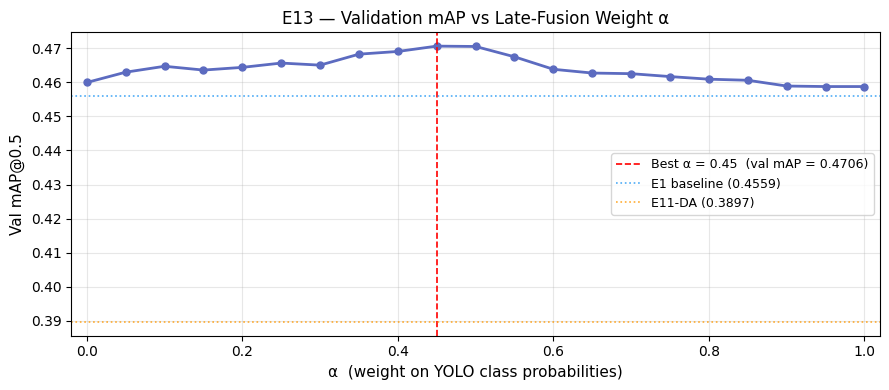

Saved: E13_alpha_sweep.png


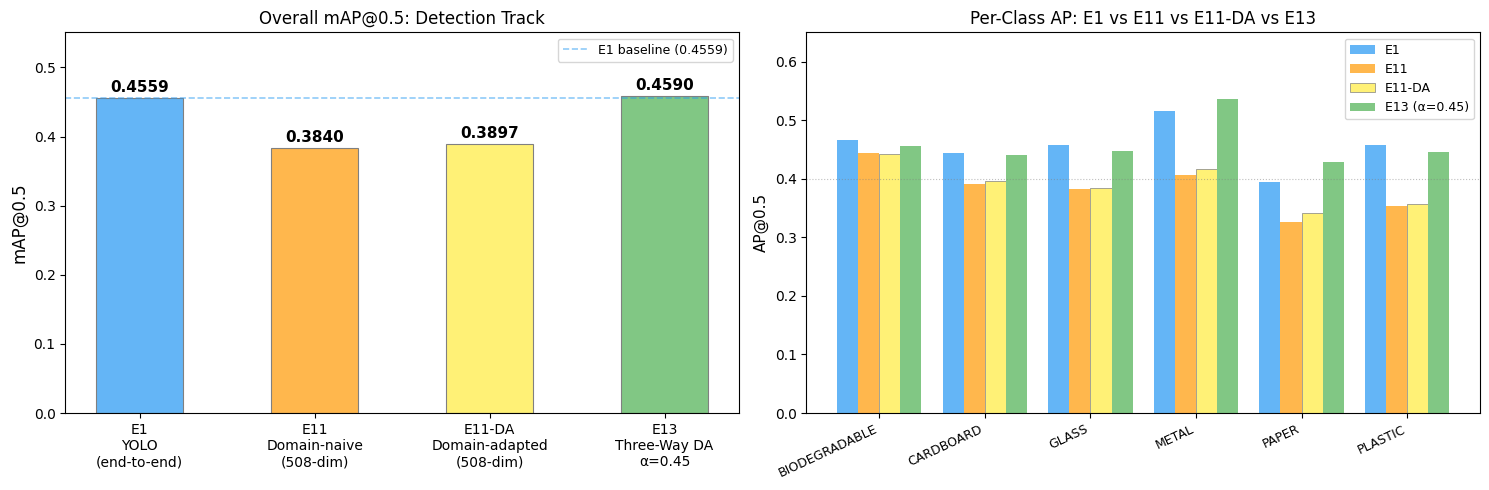

Saved: E13_vs_all_detection.png


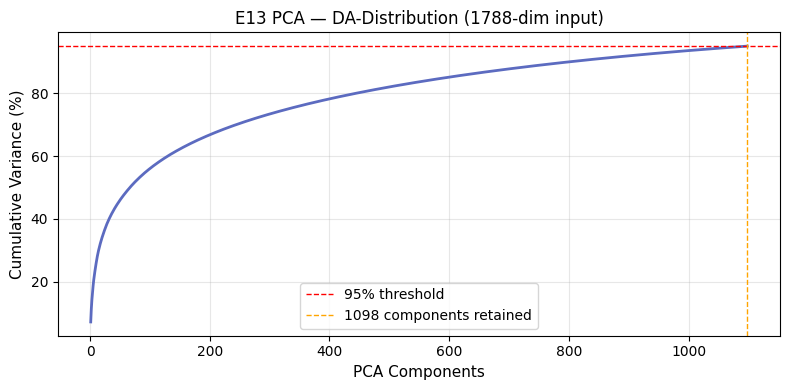

Saved: E13_pca_variance_curve.png


In [15]:

# ── CELL 15 ── Figures ───────────────────────────────────────────────────────────────────────

# Figure 1: Alpha sweep curve
fig, ax = plt.subplots(figsize=(9, 4))
alphas   = [float(a) for a in alpha_grid]
val_maps = [val_map_by_alpha[a] for a in alpha_grid]

ax.plot(alphas, val_maps, "o-", color="#5C6BC0", linewidth=2, markersize=5)
ax.axvline(best_alpha, color="red", linestyle="--", linewidth=1.2,
           label=f"Best α = {best_alpha:.2f}  (val mAP = {best_val_map:.4f})")
ax.axhline(E1_MAP50, color="#2196F3", linestyle=":", linewidth=1.2,
           alpha=0.8, label=f"E1 baseline ({E1_MAP50})")
ax.axhline(E11DA_MAP50, color="#FF9800", linestyle=":", linewidth=1.2,
           alpha=0.8, label=f"E11-DA ({E11DA_MAP50})")
ax.set_xlabel("α  (weight on YOLO class probabilities)", fontsize=11)
ax.set_ylabel("Val mAP@0.5", fontsize=11)
ax.set_title("E13 — Validation mAP vs Late-Fusion Weight α", fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(-0.02, 1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, "E13_alpha_sweep.png"), dpi=150)
plt.show()
print("Saved: E13_alpha_sweep.png")

# Figure 2: Overall mAP comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

exp_labels = ["E1\nYOLO\n(end-to-end)", "E11\nDomain-naive\n(508-dim)",
              "E11-DA\nDomain-adapted\n(508-dim)", f"E13\nThree-Way DA\nα={best_alpha:.2f}"]
map_vals   = [E1_MAP50, E11_MAP50, E11DA_MAP50, e13_map50]
colors     = ["#64B5F6", "#FFB74D", "#FFF176", "#81C784"]

ax = axes[0]
bars = ax.bar(exp_labels, map_vals, color=colors, width=0.5, edgecolor="gray", linewidth=0.8)
for bar, val in zip(bars, map_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f"{val:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.axhline(E1_MAP50, color="#2196F3", linestyle="--", linewidth=1.2,
           alpha=0.5, label=f"E1 baseline ({E1_MAP50})")
ax.set_ylabel("mAP@0.5", fontsize=12)
ax.set_ylim(0, max(map_vals) * 1.20)
ax.set_title("Overall mAP@0.5: Detection Track", fontsize=12)
ax.legend(fontsize=9)

# Figure 3: Per-class AP comparison
ax = axes[1]
x = np.arange(N_CLASSES)
w = 0.2
ax.bar(x - 1.5*w, [E1_PER_CLASS[n] for n in CLASS_NAMES],    w, label="E1", color="#64B5F6")
ax.bar(x - 0.5*w, [E11_PER_CLASS[n] for n in CLASS_NAMES],   w, label="E11", color="#FFB74D")
ax.bar(x + 0.5*w, [E11DA_PER_CLASS[n] for n in CLASS_NAMES], w, label="E11-DA", color="#FFF176",
       edgecolor="gray", linewidth=0.5)
ax.bar(x + 1.5*w, [e13_per_class[i] for i in range(N_CLASSES)], w,
       label=f"E13 (α={best_alpha:.2f})", color="#81C784")
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=25, ha="right", fontsize=9)
ax.set_ylabel("AP@0.5", fontsize=11)
ax.set_title("Per-Class AP: E1 vs E11 vs E11-DA vs E13", fontsize=12)
ax.legend(fontsize=9)
ax.set_ylim(0, 0.65)
ax.axhline(0.40, color="gray", linestyle=":", linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, "E13_vs_all_detection.png"), dpi=150)
plt.show()
print("Saved: E13_vs_all_detection.png")

# Figure 4: PCA variance curve (DA distribution)
fig, ax = plt.subplots(figsize=(8, 4))
cumvar = np.cumsum(pca_e13.explained_variance_ratio_)
ax.plot(range(1, len(cumvar)+1), cumvar * 100, color="#5C6BC0", linewidth=2)
ax.axhline(95, color="red", linestyle="--", linewidth=1, label="95% threshold")
ax.axvline(pca_e13.n_components_, color="orange", linestyle="--", linewidth=1,
           label=f"{pca_e13.n_components_} components retained")
ax.set_xlabel("PCA Components", fontsize=11)
ax.set_ylabel("Cumulative Variance (%)", fontsize=11)
ax.set_title("E13 PCA — DA-Distribution (1788-dim input)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, "E13_pca_variance_curve.png"), dpi=150)
plt.show()
print("Saved: E13_pca_variance_curve.png")



In [16]:

# ── CELL 16 ── Save results to CSVs ──────────────────────────────────────────────────────────

det_csv = os.path.join(RESULTS_DIR, "detection_results.csv")

# Row for best-alpha result
row_best = {
    "experiment":          "E13",
    "model":               f"ThreeWay_DA_LateFusion_alpha{best_alpha:.2f}",
    "timestamp":           datetime.now().strftime("%Y-%m-%d %H:%M"),
    "map50":               round(e13_map50, 4),
    "map50_95":            "",
    "precision":           "",
    "recall":              "",
    "fps":                 "",
    "model_size_mb":       "",
    "epochs_trained":      "",
    "image_size":          640,
    "feature_dim":         pca_e13.n_components_,
    "alpha":               best_alpha,
    "map50_BIODEGRADABLE": round(e13_per_class[0], 4),
    "map50_CARDBOARD":     round(e13_per_class[1], 4),
    "map50_GLASS":         round(e13_per_class[2], 4),
    "map50_METAL":         round(e13_per_class[3], 4),
    "map50_PAPER":         round(e13_per_class[4], 4),
    "map50_PLASTIC":       round(e13_per_class[5], 4),
    "svm_yolo_agree_rate": round(agree_rate, 4),
    "n_boxes":             total_det,
    "delta_vs_e1":         round(delta_vs_e1, 4),
    "delta_vs_e11da":      round(delta_vs_e11da, 4),
}
# Row for α=0 (pure SVM, diagnostic)
row_a0 = {**row_best,
    "experiment": "E13_alpha0",
    "model":      "ThreeWay_DA_SVM_only",
    "map50":      round(e13_map50_a0, 4),
    "alpha":      0.0,
}

if os.path.isfile(det_csv):
    df = pd.read_csv(det_csv)
    df = df[~df["experiment"].isin(["E13", "E13_alpha0"])]
    df = pd.concat([df, pd.DataFrame([row_best, row_a0])], ignore_index=True)
else:
    df = pd.DataFrame([row_best, row_a0])

df.to_csv(det_csv, index=False)
print(f"Appended E13 rows → {det_csv}")

# Per-class AP CSV
per_class_df = pd.DataFrame({
    "class":  CLASS_NAMES,
    "E1_AP":  [E1_PER_CLASS[n] for n in CLASS_NAMES],
    "E11_AP": [E11_PER_CLASS[n] for n in CLASS_NAMES],
    "E11DA_AP": [E11DA_PER_CLASS[n] for n in CLASS_NAMES],
    "E13_AP": [e13_per_class[i] for i in range(N_CLASSES)],
})
per_class_df["delta_E13_vs_E1"] = per_class_df["E13_AP"] - per_class_df["E1_AP"]
per_class_df.to_csv(os.path.join(RESULTS_DIR, "E13_per_class_AP.csv"), index=False)
print(f"Saved per-class AP → {os.path.join(RESULTS_DIR, 'E13_per_class_AP.csv')}")

print(f"\n{'='*55}")
print(f"  E13 COMPLETE")
print(f"  mAP@0.5 (α={best_alpha:.2f}) = {e13_map50:.4f}")
print(f"  Δ vs E1      = {delta_vs_e1:+.4f}   (E1 = {E1_MAP50})")
print(f"  Δ vs E11-DA  = {delta_vs_e11da:+.4f}   (E11-DA = {E11DA_MAP50})")
print(f"  Outcome      : {outcome.split('(')[0].strip()}")
print(f"{'='*55}")


Appended E13 rows → /Users/nadaashraf/Desktop/CV-Project/results/metrics/detection_results.csv
Saved per-class AP → /Users/nadaashraf/Desktop/CV-Project/results/metrics/E13_per_class_AP.csv

  E13 COMPLETE
  mAP@0.5 (α=0.45) = 0.4590
  Δ vs E1      = +0.0031   (E1 = 0.4559)
  Δ vs E11-DA  = +0.0693   (E11-DA = 0.3897)
  Outcome      : B
